In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [5]:
data = pd.read_csv('Mall_Customers (1).csv')

In [6]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
data = data.drop(columns=['Spending Score (1-100)', 'Gender'])  
X = data[['Age', 'Annual Income (k$)']] 

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
clustering = AgglomerativeClustering(n_clusters=10, linkage='single')
clustering.fit(X_scaled)

AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
                        connectivity=None, distance_threshold=None,
                        linkage='single', memory=None, n_clusters=10,
                        pooling_func='deprecated')

In [10]:
label = clustering.labels_

In [11]:
print(label)

[0 0 0 0 0 0 0 0 7 0 7 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0
 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 8 0 0 0 0 0 0
 0 2 0 0 0 0 0 1 1 3 1 3 1 4 4]


In [ ]:
def calculate_sse(X, labels, num_clusters):
    sse = 0
    for i in range(num_clusters):
        cluster_points = X[labels == i]
        

        centroid = np.mean(cluster_points, axis=0)
        

        sse += np.sum(np.linalg.norm(cluster_points - centroid, axis=1) ** 2)
    return sse
    
    

In [ ]:
sse_values = []

for num_clusters in range(1, 11): 
    clustering = AgglomerativeClustering(n_clusters=num_clusters, linkage='single')
    labels = clustering.fit_predict(X_scaled)
    
    sse = calculate_sse(X_scaled, labels, num_clusters)
    sse_values.append(sse)

In [14]:
for i, sse in enumerate(sse_values, 1):
    print(f"SSE for {i} clusters: {sse}")

SSE for 1 clusters: 400.0
SSE for 2 clusters: 387.99309262578083
SSE for 3 clusters: 384.3236038928899
SSE for 4 clusters: 371.96828411520426
SSE for 5 clusters: 354.00211395550895
SSE for 6 clusters: 346.15648313792167
SSE for 7 clusters: 346.07333695626284
SSE for 8 clusters: 325.5413635290379
SSE for 9 clusters: 318.2971340542268
SSE for 10 clusters: 313.9719683641197


In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [16]:
Z = linkage(X_scaled, method='single')

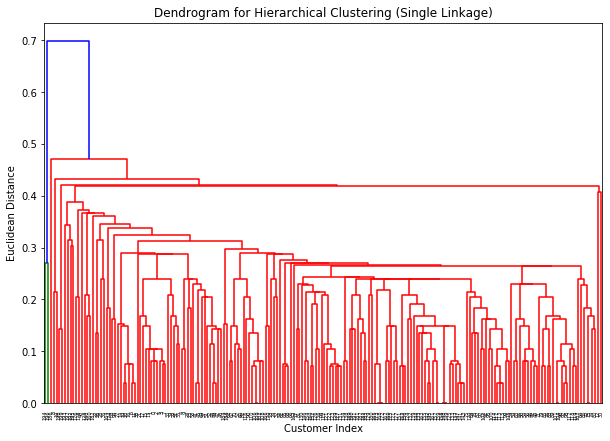

In [17]:
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering (Single Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()